In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [2]:
data_dir = "data"  
augmented_dir = "dataset_ropa_aumentado"

In [ ]:
if not os.path.exists(augmented_dir):
    os.makedirs(augmented_dir)
    for category in ["tiki_taka", "casi_tiki"]:
        os.makedirs(os.path.join(augmented_dir, category))

In [ ]:
target_size = (224, 224)
batch_size = 32
num_augmented_images = {"tiki_taka": 15, "casi_tiki": 20}

In [ ]:
augmentor = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest'
)

for category in ["tiki_taka", "casi_tiki"]:
    input_folder = os.path.join(data_dir, category)
    output_folder = os.path.join(augmented_dir, category)
    
    for filename in os.listdir(input_folder):
        img_path = os.path.join(input_folder, filename)
        img = load_img(img_path, target_size=target_size)
        img_array = img_to_array(img)
        img_array = img_array.reshape((1,) + img_array.shape)
        
        i = 0
        for batch in augmentor.flow(img_array, batch_size=1, save_to_dir=output_folder, save_prefix="aug", save_format="jpeg"):
            i += 1
            if i >= num_augmented_images[category]:
                break

In [9]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    augmented_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    augmented_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

Found 3179 images belonging to 2 classes.
Found 794 images belonging to 2 classes.


In [10]:
# Carga modelo preentrenado (MobileNetV2)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True  # Fine tuning
for layer in base_model.layers[:100]:
    layer.trainable = False

In [11]:
# Construcción del modelo
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=x)

In [12]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
epochs = 20
model.fit(train_generator, validation_data=val_generator, epochs=epochs)

model.save("modelo_ropa.keras")

print("Modelo entrenado y guardado correctamente.")

Epoch 1/20


c:\Users\bulla\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


100/100 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.8759 - loss: 0.2528 - val_accuracy: 0.6637 - val_loss: 3.7821
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.9900 - loss: 0.0377 - val_accuracy: 0.9849 - val_loss: 0.1194
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.9927 - loss: 0.0239 - val_accuracy: 0.8564 - val_loss: 1.5408
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.9890 - loss: 0.0344 - val_accuracy: 0.7078 - val_loss: 1.5171
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.9968 - loss: 0.0116 - val_accuracy: 0.8136 - val_loss: 1.4909
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.9943 - loss: 0.0132 - val_accuracy: 0.9660 - val_loss: 0.1878
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.9985 - loss: 0.0051 - val_accuracy: 0.8829 - val_loss: 1.4527
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.9992 - loss: 0.0027 - val_accuracy: 0.736

25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 671ms/step


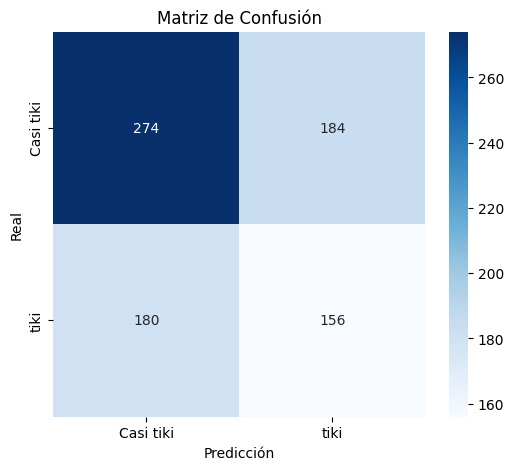

Reporte de Clasificación:
              precision    recall  f1-score   support

   Casi tiki       0.60      0.60      0.60       458
        tiki       0.46      0.46      0.46       336

    accuracy                           0.54       794
   macro avg       0.53      0.53      0.53       794
weighted avg       0.54      0.54      0.54       794



In [ ]:
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)

nuevo_umbral = 0.6
y_pred = (y_pred_probs > nuevo_umbral).astype(int)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Casi_tiki", "tiki_taka"], yticklabels=["Casi_tiki", "tiki_taka"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

# Reporte de Clasificación
print("Reporte de Clasificación:")
print(classification_report(y_true, y_pred, target_names=["Casi_tiki", "tiki_taka"]))


In [ ]:
def predecir_imagen(ruta_imagen, modelo):
    img = load_img(ruta_imagen, target_size=target_size)
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0
    
    prediccion = modelo.predict(img_array)[0][0]
    etiqueta = "tiki_taka" if prediccion >= nuevo_umbral else "Casi tiki"
    
    plt.imshow(load_img(ruta_imagen))
    plt.axis('off')
    plt.title(f"Predicción: {etiqueta} (Confianza: {prediccion:.4f})")
    plt.show()
    
    print(f"Predicción: {etiqueta} (Confianza: {prediccion:.4f})")
    return etiqueta

# Cargar el modelo entrenado para predicciones
modelo_cargado = keras.models.load_model("modelo_ropa.keras")

# Ejemplo de uso
# predecir_imagen("ruta_a_la_imagen.jpg", modelo_cargado)


